# Tutorial 1: Numerical Python (NumPy)

-----------------------------------------------------------

## Overview

Are you ready to supercharge your research and data analysis? As a biologist, you're swimming in data—DNA sequences, protein structures, population stats, or experimental results. Processing all that manually or with spreadsheets? That’s the slow lane. Let me introduce you to NumPy, your new powerhouse for scientific computing!

**Why Should a Biologist Care About NumPy?**
1. Handle Biological Data Like a Pro

Whether you’re analyzing gene expression data, creating protein matrices, or modeling population dynamics, NumPy makes it seamless to store, manipulate, and analyze huge datasets—faster and cleaner than Excel or vanilla Python.

3. Speed Up Your Workflow

NumPy is like the Ferrari of data handling. Instead of painfully iterating through lists, NumPy’s vectorized operations handle massive datasets in milliseconds. Run that alignment calculation or simulation without breaking a sweat.

4. Crunch Numbers with Ease

Biologists often need statistical measures: mean, standard deviation, correlations… NumPy gives you all that in a few lines of code. It’s like having a mini statistical lab built into Python.

5. Visualize Patterns in Your Data

Pair NumPy with tools like matplotlib, and you can visualize trends in gene frequencies, protein concentrations, or ecological patterns beautifully and intuitively.

## Learning Objectives
In this lesson, you’ll discover how to:

- Build and manipulate arrays to represent anything from a DNA sequence to a cell population matrix.
- Reshape and organize your data to suit your experimental needs.
- Perform fast, efficient calculations on biological datasets without writing endless loops.
- Dummy-code (one-hot-encode) categorical data into numerical data with a protein sequence

## Prerequisites
- basic python

## Getting Started
- Run the next code box to prepare the quiz
- View the PowerPoint overview

In [3]:
#Run this cell if you have not done a matching list quiz in this Jupyter notebook session

#install the required packages
import requests
import json
import ipywidgets as widgets
from IPython.display import display
import random
print("done installing required packages")


#This should all be imported simply with the module import below, but it won't work just in Anaconda Jupyter notebooks
class MatchingQuiz:
    def __init__(self, import_type:str, import_path:str, instant_feedback=False, shuffle_questions=False, shuffle_answers=False):
        self.questions = []
        self.answers = {}
        self.user_answers = []
        self.feedback_labels = []
        self.instant_feedback = instant_feedback
        self.shuffle_questions = shuffle_questions
        self.shuffle_answers = shuffle_answers
        self.distractors = []
        self.explanations = {}
        self.load_questions_from_json(import_type, import_path)

    def load_questions_from_json(self, import_type, import_path):
        if import_type == 'json':
            # Load the JSON file
            with open(import_path, 'r') as f:
                data = json.load(f)
        
        elif import_type == 'url':
            res = requests.get(import_path)
            data = res.json()
        
        else:
            print("Invalid parameter value, import_type must be a str value equal to 'json' or 'url'.")
            
        # Extract questions, answers, and explanations
        for item in data["questions"]:
            question = item["question"]
            answer = item["answer"]
            explanation = item.get("explanation", "No explanation provided.")
            self.questions.append((question, answer))
            self.answers[question] = answer
            self.explanations[question] = explanation

    def setup_quiz(self):
        # Optionally shuffle questions
        questions = self.questions[:]
        if self.shuffle_questions:
            random.shuffle(questions)

        # Clear previous user answers and feedback labels
        self.user_answers = []
        self.feedback_labels = []

        # Display each question with a dropdown for selecting the answer
        question_widgets = []
        for i, (question, correct_answer) in enumerate(questions):
            # Create answer options with distractors
            answer_options = list(self.answers.values()) + self.distractors
            if self.shuffle_answers:
                random.shuffle(answer_options)

            # Create the label, dropdown, and feedback label
            question_label = widgets.Label(value=question)
            answer_dropdown = widgets.Dropdown(options=['--Select--'] + answer_options)
            feedback_label = widgets.Label(value="")
            
            # Store reference to each dropdown and its corresponding feedback label
            self.user_answers.append(answer_dropdown)
            self.feedback_labels.append(feedback_label)
            
            question_widgets.append(widgets.HBox([question_label, answer_dropdown, feedback_label]))

            # Define the dropdown change event for instant feedback
            def on_answer_change(change, answer_dropdown=answer_dropdown, feedback_label=feedback_label, correct_answer=correct_answer):
                if self.instant_feedback and change['name'] == 'value':
                    selected_answer = answer_dropdown.value
                    if selected_answer == correct_answer:
                        feedback_label.value = "✔️"  # Checkmark for correct
                        feedback_label.layout.color = 'green'
                    elif selected_answer == '--Select--':
                        feedback_label.value = ""  # Reset for no selection
                    else:
                        feedback_label.value = "❌"  # Cross for incorrect
                        feedback_label.layout.color = 'red'
            
            # Link the dropdown to the feedback event
            answer_dropdown.observe(on_answer_change, names='value')

        # Create a button to check answers
        check_button = widgets.Button(description="Check Answers")
        reset_button = widgets.Button(description="Reset Quiz")
        result_label = widgets.HTML(value="")

        # Define the button click event for "Check Answers"
        def on_check_button_click(b):
            correct = 0
            explanations_output = ""
            
            for i, (question, _) in enumerate(questions):
                selected_answer = self.user_answers[i].value
                if selected_answer == self.answers[question]:
                    correct += 1
                else:
                    # Add explanation for incorrect answers
                    explanation = self.explanations.get(question, "No explanation provided.")
                    explanations_output += f"<li>{question}: {explanation}</li>"
            
            # Update the result label with color based on the score
            if correct == len(questions):
                result_label.value = f"<span style='color: green; font-weight: bold;'>✔️ Correct!</span>"
            else:
                result_label.value = f"<span style='color: red; font-weight: bold;'>❌ Incorrect! Try again.</span>"
                result_label.value += f"<br><ul>{explanations_output}</ul>"
        
        # Define the button click event for "Reset Quiz"
        def on_reset_button_click(b):
            for dropdown, feedback in zip(self.user_answers, self.feedback_labels):
                dropdown.value = '--Select--'
                feedback.value = ""
            result_label.value = ""

        check_button.on_click(on_check_button_click)
        reset_button.on_click(on_reset_button_click)

        # Display all components
        display(widgets.VBox(question_widgets + [check_button, reset_button, result_label]))

# Function to create and run the quiz
def run_quiz(import_type, import_path, instant_feedback=False, shuffle_questions=False, shuffle_answers=False):
    quiz = MatchingQuiz(import_type, import_path, instant_feedback, shuffle_questions, shuffle_answers)
    quiz.setup_quiz()

#The module quiz_module.py is located in the Module_1 folder
#from quiz_module import run_quiz
print("done installing quiz_module")

done installing required packages
done installing quiz_module


----------------------------------------------------------------------------------


## About Numpy
Numerical Python​, or "numpy" is one of the most popular modules used in Python. Numpy is considered a foundational module for Python high-end scientific computing.​ 
<br>  ​
The common standard in Python is to import numpy with the alias **np**.​


In [6]:
# Standard import of numpy
import numpy as np

# check the version
print(np.__version__)

1.26.4


Among the many components it provides is the **ndarray**.​

  - This is a high-performance array or vector and serves as one of the main classes for scientific computing.​

  - Only holds one type of element, much like a standard array.​

  - It is created with the **array()** function.


In [8]:
# Example using numpy for arrays
import numpy as np

# Specify the elements of the arrays
arr1 = np.array((1, 2, 3, 4, 5))
#arr2 has arrays as elements
arr2 = np.array([[1,2,3],[4,5,6]]) 
# Create an array using a range. Remember, range(20) will create an integer array of length 20
arr3 = np.array(range(10))  

print(arr1)
print(arr2)
print(arr3)

[1 2 3 4 5]
[[1 2 3]
 [4 5 6]]
[0 1 2 3 4 5 6 7 8 9]


### Other ways to create arrays

There are some other functions to create convenient arrays that are needed for tasks

**arange(stop,start,stepsize)**   is used to create arrays with evenly spaced values over a specified range. It is one of the most commonly used functions in NumPy for generating sequences of numbers. Start is optional (assumes zero) and stepsize default is 1

**ones()**      creates an array of all ones

**zeros()**     creates an array of all zeros. This would be useful for initializing a counting array

**identity()**  creates an identity matrix
<div class="alert alert-block alert-info"> <b>Tip:</b> Try each of the following arrays by removing the #</a>. </div>

In [10]:
# More array creation
import numpy as np

arr=np.arange(2,12, 2)
print(arr)
#np.ones((2,4))  # shortcut to create a 2x4 array and populate with 1's
#np.zeros((2,3)) # shortcut to create a 2x3 array and populate with 0's
#np.identity(5)  # shortcut to create identity array (1's on diagonal, 0's elswhere)

[ 2  4  6  8 10]


## Test Your Knowledge

Create an np array of the numbers 100 to 300, by sevens. 

In [93]:
import numpy as np
#creating np array of numbers, x, with 100 to 300, by sevens
x=np.arange(100,300,7)
print(x[-1])
len(x)

296


29

## Indexing

For these one dimensional arrays, we index as in other python arrays​. That is, you can identify individual elements of the array by position \[#], counting backwards from the end \[-#], by range, etc. 

The following code is several ways of slicing an array. Remove the # in front of each row to see the results of these ways to index.


In [14]:
# Indexing (slicing)
line = np.arange(100,310,10)
line[0] #the zeroth element
line[[1,2,1]] #returns an array of the elements in the 1, 2, and 1 (again) elements
#line[:4] #for the first 4 elements
#line[-1:-10:-1]  # the third number is the step, so this will return the last 10 elements of the array



array([110, 120, 110])

## Mutability

Numpy arrays are mutable (that is, can be edited). Simply provide a new value for the index. Remember, though, that numpy arrays can only have one type. 
<div class="alert alert-block alert-info"> <b>Tip:</b> Try replacing a value in line with a 'string' to see the error</a>. </div>


In [16]:
print(line[:7])

[100 110 120 130 140 150 160]


In [17]:
line[3]=0
print(line[:7])

[100 110 120   0 140 150 160]


# Test Your Knowledge
(see the solution in the next markdown box)

>  1. Create an np array ("let_arr") of 10 elements (letters a-j). Note: there is no shortcut for a range of letters
>  2. Change the 2nd element to 'q' & print to the console
>  3. Change the 4th element to the string 'cat'. (does it work, what type is it?)

In [19]:
import numpy as np


## Reshaping

Biological datasets come in many different forms—whether you’re working with gene expression matrices, 3D protein structures, or time-lapse imaging data. However, the structure of your data doesn’t always match the way you need to analyze or visualize it. That’s where reshaping a NumPy array comes in!

**Reshape = Flexibility for Analysis**

By reshaping your NumPy arrays, you adapt your data to fit specific tasks—statistical analysis, visualization, or preparing input for machine learning models. Instead of wasting time manually reorganizing data, you let NumPy do the heavy lifting so you can focus on your biology!

Numpy has built-in tools, as we've said, to work with arrays. A single array can be rearranged 
We can reshape an array with **array.reshape()**

In [21]:
# Reshaping array
data = np.arange(1,2*4*2+1)  # data all in a long array of results
print(data)
reshaped = data.reshape(4, 4)  # reshaping the 16 data points into the 4 samples, 4 treatments
print(reshaped)
reshaped.shape
#cube = line.reshape(2,4,4)
#cube.shape

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]]


(4, 4)

### How to index with 2 or more dimensions

To identify a single element of the array, start with the first axis value, separate from the 2nd with a comma:

\[row number, column number]

You can also index a whole row or column using : in the other dimension.

In [23]:
# Indexing Multiple Dimensions
reshaped[1]
#reshaped[0,:] # equivalent to square[0] because the other 2 dimensions are assumed
#reshaped[3,2]
#reshaped[3][2] # equivalent

#cube[0]
#cube[0,2,1]
#cube[:,0,0]

array([5, 6, 7, 8])

# Test Your Knowledge

> 1. Create a 2x5 array of the numbers 1-10
> 2. Transpose the array, change rows to columns, columns to rows
> 3. Reshape the array, make it a 2x2x3 array
> 4. Add the numbers 11 and 12 to the missing cells

## Boolean indexing

We can also index using booleans​. We'll show it two different ways of creating a Boolean array. First, we create a True/False array of the same length as the target array. Then, that functions to subset the array

In [26]:
# Boolean Index
line = np.array([1,2,3,4,5])
subset= np.array ([True, False, True, False, True])
line[subset]
#tf = line > 2 #this will create an array that can be used to select part of the line array
#line[tf]

array([1, 3, 5])

## Iterating a NumPy array
Bioinformaticists often deal with large, complex datasets, and iterating over a NumPy array can be incredibly useful in specific scenarios where you need fine-grained control over your data analysis. You can iterate in python, too, but Numpy is more efficient (that is, faster with fewer resources)

A bioinformaticist might want to iterate over a NumPy array to analyze or process each row, column, or element individually. 


In [28]:
import numpy as np

arr = np.array([1, 2, 3])  # 1-dimensional array

for x in arr:
    print(x)

1
2
3


In [29]:
# 2-dimensional array
arr = np.array([[1, 2, 3], [4, 5, 6]])

for x in arr:  #note: regardless of what variable you put in place of x, the same thing will be printed.
    print(np.sin(x))

# also 2-d array
#for y in arr:
#    for x in y:
#        print(y)

[0.84147098 0.90929743 0.14112001]
[-0.7568025  -0.95892427 -0.2794155 ]


One of the many uses of iteration might be to **normalize** the expression levels for each gene across different samples in a gene expression matrix. One of the normalization techniques is to divide ALL the expression levels by the sum of the whole row that is, across all the different cell samples or conditions. Another version would be to normalize by the mean of the expression (try that, too!)


In [31]:
import numpy as np

# Create a tiny expression matrix (rows = genes, columns = conditions)
expression_matrix = np.array([
    [10, 15, 20, 25, 30, 35],  # Gene 1
    [5, 10, 15, 20, 25, 30],   # Gene 2
    [0, 50, 100, 150, 200, 250], # Gene 3
    [8, 16, 24, 32, 40, 48],   # Gene 4
    [3, 6, 9, 12, 15, 18]      # Gene 5
])

# Print the matrix
print("Original Expression Matrix:")
print(expression_matrix)

# Normalize each gene's expression levels (row-wise normalization)
normalized_matrix = []   #initialize an empty array in python
for row in expression_matrix:
    normalized_row = row / np.sum(row)  # Normalize by dividing the sum of the row. sum() is a normal python function here used in its Numpy form
    normalized_matrix.append(normalized_row)

normalized_matrix = np.array(normalized_matrix)

# Print the normalized matrix
print("\nNormalized Expression Matrix (row-wise):")
print(normalized_matrix)


Original Expression Matrix:
[[ 10  15  20  25  30  35]
 [  5  10  15  20  25  30]
 [  0  50 100 150 200 250]
 [  8  16  24  32  40  48]
 [  3   6   9  12  15  18]]

Normalized Expression Matrix (row-wise):
[[0.07407407 0.11111111 0.14814815 0.18518519 0.22222222 0.25925926]
 [0.04761905 0.0952381  0.14285714 0.19047619 0.23809524 0.28571429]
 [0.         0.06666667 0.13333333 0.2        0.26666667 0.33333333]
 [0.04761905 0.0952381  0.14285714 0.19047619 0.23809524 0.28571429]
 [0.04761905 0.0952381  0.14285714 0.19047619 0.23809524 0.28571429]]


## NumPy Math Functions

NumPy provides many functions you would expect in highly statistical applications such as data science. We have already been using some of them, such as enumerate and reshape

Operations that would take several lines of nested loops in Python can be done in one line with NumPy. Whether you're doing matrix multiplication, statistical analysis, or random sampling, NumPy's tools simplify and accelerate your workflow. We will focus here on ones you might need for bioinformatics. Once you see how these work, you will easily be able to edit and use other functions. The full list is in the [numpy documentation](https://numpy.org/doc/2.1/reference/routines.math.html)

- Mathematical functions
    * np.sum: Calculates the sum of elements along a specific axis
    * np.mean: Computes the mean (average) of array elements
    * np.sqrt: Computes the square root of each element in an array
    * np.min / np.max: Find the minimum and maximum values in an array
    * np.std: Calculates the standard deviation
    * np.log10: Calculates the log of the value *commonly needed in biolinformatics*
    * 
- Logical and Comparison Functions
    * np.where: Returns the indices of elements meeting a condition, or replaces elements based on a condition
    * np.any / np.all: Checks if any or all elements of an array meet a condition
- Tools to generate arrays
    - np.random.normal


In [33]:
#You can make an array, s, which is a sample of the normal distribution 
x= 27 # the mean
SD = 1.3 #the standard deviation
s = np.random.normal(x, SD, 100)
s[0:3]

array([28.45741481, 28.14859822, 27.11021845])

In [34]:
# NumPy Functions
np.mean(s) #mean of the array
#np.mean(s[20:30]) #mean of a subset of the array

26.97663843423092

In [35]:
#calculate the standard deviation of the array
np.std(s)       #Although the SD specified was 1.3, it is a random sampling

1.1784219916397525

<div class="alert alert-block alert-warning"> <b>Attention:</b> We'll jump ahead in the tutorial to show a histogram of the array s created using the matplotlib.pyplot libraries</a>. </div>


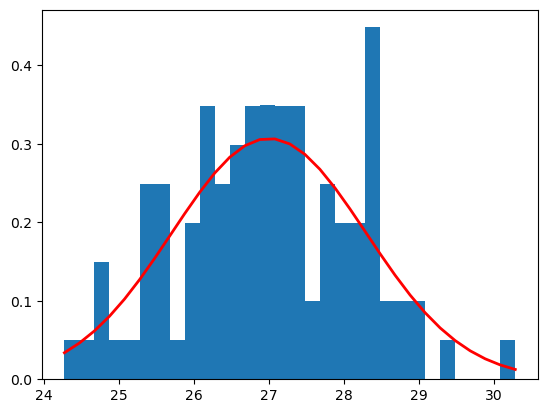

In [37]:
#Display the histogram of the samples, along with the probability density function:
import matplotlib.pyplot as plt
count, bins, ignored = plt.hist(s, 30, density=True)
plt.plot(bins, 1/(SD * np.sqrt(2 * np.pi)) *
               np.exp( - (bins - x)**2 / (2 * SD**2) ),
         linewidth=2, color='r')
plt.show()

<div style="font-size:18px">More on Arrays</div> 

Arrays can also be split, i.e. taking a single array and breaking it up into multiple sub-arrays​

The following code takes one array and splits it into 3 (equal parts)​

In [39]:
import numpy as np

arr = np.array([1, 2, 3, 4, 5, 6])
newarr = np.array_split(arr, 3)
print(newarr)

[array([1, 2]), array([3, 4]), array([5, 6])]


NumPy allows you to conduct array searches using a **where()** method​

The return value is an array of indexes where the search condition was satisfied​

In [41]:
import numpy as np

arr = np.array([1, 2, 3, 4, 5, 4, 4])
x = np.where(arr == 4)
print(x)

(array([3, 5, 6], dtype=int64),)


Finally you can sort arrays using the sort() method​

  - The return value is a copy of the array sorted​

Note the sort is only ascending. To do a descending sort you need to reverse the array using slicing​

In [43]:
import numpy as np
arr = np.array([3, 2, 0, 1])
print(np.sort(arr))
print(np.sort(arr)[::-1])  # sort descending

[0 1 2 3]
[3 2 1 0]


## Quiz
NEEDS A PRACTICE SET

# One-hot Encoding (e.g., Dummy Coding)

We can use two np array tools you've just learned about to "one-hot encode" categorical data into numerical data. This is a common bioinformatics task, since biological data is often categorical (sequences, low-medium-high risk of disease, etc). This kind of reformatting allows us to use numerical processes to understand data very efficiently. Also, it is necessary to have numerical data for most machine learning approaches.

First one develops an np array of the possible categories, then the categorical data is represented with an identity array (where there is one value of 1 to show "hot".) We then make a dictionary of each of the possible categories with its distinct identity array (e.g., \[0,1,0,0] for being from the second category

Here is an example with "one-hot encoding" of a short DNA sequence to illustrate some of the tools.  

In [46]:
# One-hot encoding example

# Step 1: Define the sequence
sequence = "ACGTACGTACGTTACGCC"

# Step 2: Create the right-sized identity matrix
dna_identity = np.identity(4) # since there are 4 different bases
dna_types = np.array(['A','C','T','G'])


# Step 3: Create a one-hot encoding dictionary for each nucleotide in your array of dna_types
# Notice that we use enumeration to keep the association between the index (i) and value (nt) from the array of DNA types
dna_mapping = {nt: dna_identity[i] for i, nt in enumerate(dna_types)}

#Optional: Display the mapping dictionary keys
#for nt, one_hot in dna_mapping.items():
#    print(f"{nt}:{one_hot}")

# Step 4: One-hot encode the given DNA sequence
dna_one_hot = np.array([dna_mapping[nt] for nt in sequence])
print(dna_one_hot[:4]) #just the first 4 items

# Sum up the 1s for each column to get the count of each nucleotide
dna_column_sums = np.sum(dna_one_hot, axis=0)
# Show that A, T & G are 4, while C appears 6 times in the sequence
print(dna_column_sums)


[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]]
[4. 6. 4. 4.]


<div class="alert alert-block alert-info"> <b>Tip:</b> Try reordering the dna_types array AND using that list to identify which base is shown in the dna_column_sums</a>. </div>

One-hot encoding of sequences is useful for a variety of bioinformatics applications. This representation converts categorical sequence data (e.g, A, C, G, T into a numerical format), enabling easier manipulation and computation. We will use this approach to compute transitions for Markov Models. 

But, first, you need to practice these skills by creating your own code for **protein** one-hot encoding.

## Test your knowledge

Can you make a similar tool for dummy coding a protein sequence? You'll use this to answer the quiz questions.
- Import a protein sequence from NCBI as your sequence (the quiz questions are based on the FASTA sequence human leptin from the **protein** database, id XP_005250397.1.... To fetch them, you can use the project solution from module 1.)
- Create a mapping matrix for the amino acids A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
- Create a one-hot array for the protein sequence.
- Print the head or the tail of the one-hot matrix (the first 10 rows) for practice & to confirm
- Get the index of lysine (K) from the array you make of the amino acids.
- Count number of lysines for the whole sequence & display the value
- Check that answer by using the string.count(character) method from module 1

In [50]:
# The answers are in the next code box, but try to answer it on your own!
# Step 1: Create a 20x20 identity matrix

# Step 2: Define an np array containing one-letter amino acid codes

# Step 3: Map each amino acid to its corresponding one-hot encoding
# Step 4: Collect the leptin FASTA protein sequence

# Step 5: One-hot encode the leptin sequence using your 
# Optional: Step 6: print the first 10 rows of the one_hot_code
# Step 7: Add all the columns to count the amino acid frequencies
# Step 8: Find the index of the requested amino acid and print its frequency from the column sums

In [51]:
#Answers
# Step 1: Create a 20x20 identity matrix
identity_matrix = np.identity(20)

# Step 2: Define an np array containing one-letter amino acid codes
amino_acids = np.array([
    'A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L',
    'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y'
])

# Step 3: Map each amino acid to its corresponding one-hot encoding
aa_map = {aa: identity_matrix[i] for i, aa in enumerate(amino_acids)}

# Optional: Display the mapping dictionary
#for aa, one_hot in aa_map.items():
#    print(f"{aa}: {one_hot}")

#Step 4: Collect the leptin FASTA protein sequence as lep_seq
from Bio import Entrez, SeqIO
Entrez.email = "drchase55@gmail.com"

handle = Entrez.efetch(db="protein", id="XP_005250397.1", rettype="fasta")

leptin = SeqIO.read(handle, "fasta")
handle.close()
lep_seq=leptin.seq

# Step 5: Encode the given sequence
leptin_one_hot = np.array([aa_map[aa] for aa in lep_seq])

#Step 6: print the first 10 rows of the one_hot_code
#print(leptin_one_hot[0:10])

#Step 7: Add all the columns to count the amino acid frequencies
lep_column_sums = np.sum(leptin_one_hot, axis=0)
# lep_column_sums has the count of all AAs in the leptin protein

#Step 8: Get the index of the amino acid you want
index = np.where(amino_acids == 'C')[0][0]

AA_count = lep_column_sums[index]   

print(AA_count)
#check, using the simple counting string method from Module 1
lep_seq.count("C")

3.0


3

# Summary

In this tutorial, you have learned the many functions associated with the NumPy array. 

The next module introduces you to [Pandas](./Submodule_2_Tutorial2_Pandas.ipynb)

## Clean up
Remember to shut down your Jupyter Notebook instance when you are done for the day to avoid unnecessary charges. You can do this by stopping the notebook instance from the Cloud console.